# Stock Only Backtest

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from pathlib import Path
import os

# --- 1. Data Loading (Adapted from data.py to run standalone) ---
def get_all_closes(data_dir="sp500_data", start_date="2025-01-01", end_date="2025-12-31"):
    """
    Reads all CSVs from the data directory and combines '4. close' into a single DataFrame.
    """
    data_path = Path(data_dir)
    if not data_path.exists():
        raise FileNotFoundError(f"{data_dir} directory not found.")
    
    series_list = []
    print("Loading data...")
    for file in data_path.iterdir():
        if file.suffix.lower() != ".csv":
            continue
        symbol = file.stem
        try:
            df = pd.read_csv(file, parse_dates=["date"], index_col="date")
            # Ensure index is datetime
            df.index = pd.to_datetime(df.index)
            s = df["4. close"].astype(float)
            s = s[s.index >= pd.Timestamp(start_date)]
            s = s[s.index <= pd.Timestamp(end_date)]
            s.name = symbol
            series_list.append(s)
        except Exception as e:
            print(f"Skipping {symbol}: {e}")
            
    if not series_list:
        return pd.DataFrame()
    
    print(f"Loaded {len(series_list)} assets. Aligning data...")
    combined = pd.concat(series_list, axis=1)
    
    # Clean up data
    # Drop columns with too many NaNs (>10%)
    nan_ratio = combined.isna().mean()
    cols_to_keep = nan_ratio[nan_ratio <= 0.10].index
    combined = combined[cols_to_keep]
    
    # Drop rows where everything is NaN
    combined = combined.dropna(how="all")
    combined = combined.sort_index()
    
    # Forward fill to handle small gaps in trading data
    combined = combined.ffill()
    
    return combined

# --- 2. Signal Calculation ---
def calculate_momentum_zscores(prices, window=90):
    """
    Calculates cross-sectional Z-scores of momentum.
    Momentum = Price(t) / Price(t-window) - 1
    """
    # Calculate Momentum (Return over window)
    momentum = prices.pct_change(window)
    
    # Calculate Z-Scores Cross-Sectionally (axis=1)
    # (Value - Mean) / Std
    mean = momentum.mean(axis=1)
    std = momentum.std(axis=1)
    
    # Broadcast mean and std for element-wise operation
    zscores = momentum.sub(mean, axis=0).div(std, axis=0)
    
    return zscores

# --- 3. Backtest Engine ---
def run_backtest(prices, zscores, percentile=0.70):
    """
    Simulates trading based on Z-score threshold.
    Entry: Z-score > Threshold
    Exit: Z-score < Threshold
    """
    threshold = norm.ppf(percentile)
    print(f"Backtesting with Threshold Z-Score: {threshold:.4f} ({percentile*100}th percentile)")
    
    trades = []
    active_positions = {} # symbol -> {entry_date, entry_price}
    
    # Iterate through each day
    # Start from the first day we have valid z-scores
    valid_dates = zscores.dropna(how='all').index
    
    for date in valid_dates:
        if date not in prices.index:
            continue
            
        daily_scores = zscores.loc[date]
        daily_prices = prices.loc[date]
        
        # 1. Check Exits for held positions
        # Create a list to avoid modifying dictionary while iterating
        symbols_to_exit = []
        for symbol, position_data in active_positions.items():
            # If data is missing for today, skip (hold) or force exit? We'll hold.
            if symbol not in daily_scores or pd.isna(daily_scores[symbol]):
                continue
                
            score = daily_scores[symbol]
            
            # EXIT CONDITION: Score drops below threshold
            if score < threshold:
                exit_price = daily_prices[symbol]
                if pd.isna(exit_price):
                    continue # Can't exit if no price
                
                trades.append({
                    "Symbol": symbol,
                    "Entry Date": position_data["entry_date"],
                    "Entry Price": position_data["entry_price"],
                    "Exit Date": date,
                    "Exit Price": exit_price,
                    "PNL": exit_price - position_data["entry_price"],
                    "Return": (exit_price - position_data["entry_price"]) / position_data["entry_price"]
                })
                symbols_to_exit.append(symbol)
        
        # Process Exits
        for symbol in symbols_to_exit:
            del active_positions[symbol]
            
        # 2. Check Entries
        # Identify assets above threshold
        # We only buy if we don't already hold it
        candidates = daily_scores[daily_scores > threshold].index
        
        for symbol in candidates:
            if symbol in active_positions:
                continue # Already holding
            
            entry_price = daily_prices[symbol]
            if pd.isna(entry_price):
                continue
                
            active_positions[symbol] = {
                "entry_date": date,
                "entry_price": entry_price
            }

    # Close all remaining positions at the end
    last_date = prices.index[-1]
    last_prices = prices.iloc[-1]
    
    for symbol, position_data in active_positions.items():
        exit_price = last_prices[symbol]
        if pd.isna(exit_price):
            continue
            
        trades.append({
            "Symbol": symbol,
            "Entry Date": position_data["entry_date"],
            "Entry Price": position_data["entry_price"],
            "Exit Date": last_date,
            "Exit Price": exit_price,
            "PNL": exit_price - position_data["entry_price"],
            "Return": (exit_price - position_data["entry_price"]) / position_data["entry_price"],
            "Status": "Open (Closed at End)"
        })
        
    return pd.DataFrame(trades)

# --- 4. Execution ---

# Load Data
# Assuming 'sp500_data' is in the current directory or adjust path


In [35]:
prices = get_all_closes(data_dir="../sp500_data", start_date="1999-01-01", end_date="2024-12-31")

if not prices.empty:
    # Calculate Signals
    # Using 90-day momentum window (approx 3 months)
    zscores = calculate_momentum_zscores(prices, window=90)
    
    # Run Backtest
    trades_df = run_backtest(prices, zscores, percentile=0.70)
    
    # Output Results
    print(f"\nTotal Trades: {len(trades_df)}")
    if not trades_df.empty:
        print(f"Average PNL per trade: ${trades_df['PNL'].mean():.2f}")
        print(f"Average Return per trade: {trades_df['Return'].mean()*100:.2f}%")
        print(f"Win Rate: {(trades_df['PNL'] > 0).mean()*100:.2f}%")
        print(f"Total Return: {trades_df['Return'].sum()*100:.2f}%")
        print(f"Number of Winning Trades: {(trades_df['PNL'] > 0).sum()}")
        print(f"Number of Losing Trades: {(trades_df['PNL'] <= 0).sum()}")
        trades_df['Holding Period'] = (trades_df['Exit Date'] - trades_df['Entry Date']).dt.days
        print(f"Average Holding Period: {trades_df['Holding Period'].mean():.2f} days")

        
        
        # Optionally save to CSV
        # trades_df.to_csv("backtest_results.csv", index=False)
else:
    print("No data loaded. Please check the 'sp500_data' directory.")

Loading data...
Loaded 492 assets. Aligning data...
Backtesting with Threshold Z-Score: 0.5244 (70.0th percentile)

Total Trades: 40653
Average PNL per trade: $-0.02
Average Return per trade: 0.34%
Win Rate: 42.19%
Total Return: 13665.75%
Number of Winning Trades: 17153
Number of Losing Trades: 23500
Average Holding Period: 18.93 days


In [34]:
trades_df.head()

,Symbol,Entry Date,Entry Price,Exit Date,Exit Price,PNL,Return,Status,Holding Period
0,CHRW,2000-03-10,49.44,2000-03-13,48.63,-0.81,-0.016383,NaN,3
1,VRSN,2000-03-10,239.90,2000-03-15,194.80,-45.10,-0.187995,NaN,5
2,CTXS,2000-03-10,107.50,2000-03-15,88.13,-19.37,-0.180186,NaN,5
3,MSI,2000-03-10,175.00,2000-03-16,151.75,-23.25,-0.132857,NaN,6
4,ADI,2000-03-10,172.90,2000-03-16,79.00,-93.90,-0.543088,NaN,6


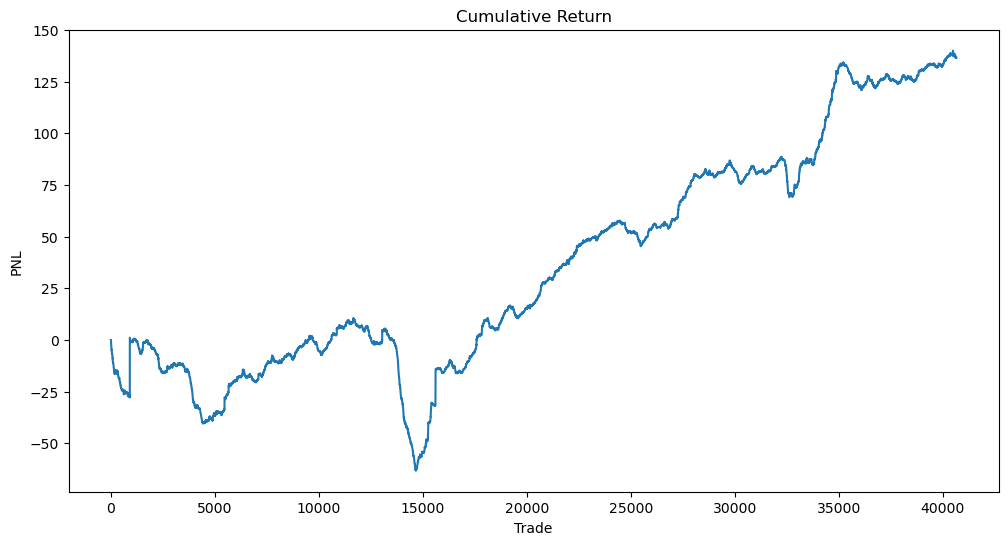

In [46]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
# plot the cumsum PNL
plt.plot(trades_df['Return'].cumsum())
plt.title('Cumulative Return')
plt.xlabel('Trade')
plt.ylabel('PNL')
plt.show()


# Option backtest with assumptions
Assumptions:
- Delta range (0.25, 0.4)
- Premium: 6%
- ES target: 1%
- Roll over min: 15 days
- Budget per position: $250,000,0
- Positions: 20
- dtm range: (15, 30)
- momentum window: 30
- zscore_window: 15
- gamma range: (0.001, 0.015)

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from pathlib import Path

# --- 1. BSM Model & Helpers ---
def bsm_d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))

def bsm_d2(S, K, T, r, sigma):
    return bsm_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bsm_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(0, S - K)
    d1 = bsm_d1(S, K, T, r, sigma)
    d2 = bsm_d2(S, K, T, r, sigma)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_call_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = bsm_d1(S, K, T, r, sigma)
    return norm.cdf(d1)

def bsm_call_gamma(S, K, T, r, sigma):
    if T <= 0:
        return 0.0
    d1 = bsm_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def find_strike_for_delta(S, T, r, sigma, target_delta):
    """Find Strike K that gives the target delta."""
    def objective(K):
        return bsm_call_delta(S, K, T, r, sigma) - target_delta
    
    # Search range: 50% to 150% of Spot
    try:
        return brentq(objective, S * 0.5, S * 1.5)
    except ValueError:
        return S * 1.05 # Fallback

# --- 2. Data Loading ---
def get_all_closes(data_dir="sp500_data", start_date="2025-01-01", end_date="2025-12-31"):
    """
    Reads all CSVs from the data directory and combines '4. close' into a single DataFrame.
    """
    data_path = Path(data_dir)
    if not data_path.exists():
        raise FileNotFoundError(f"{data_dir} directory not found.")
    
    series_list = []
    print("Loading data...")
    for file in data_path.iterdir():
        if file.suffix.lower() != ".csv":
            continue
        symbol = file.stem
        try:
            df = pd.read_csv(file, parse_dates=["date"], index_col="date")
            # Ensure index is datetime
            df.index = pd.to_datetime(df.index)
            s = df["4. close"].astype(float)
            s = s[s.index >= pd.Timestamp(start_date)]
            s = s[s.index <= pd.Timestamp(end_date)]
            s.name = symbol
            series_list.append(s)
        except Exception as e:
            print(f"Skipping {symbol}: {e}")
            
    if not series_list:
        return pd.DataFrame()
    
    print(f"Loaded {len(series_list)} assets. Aligning data...")
    combined = pd.concat(series_list, axis=1)
    
    # Clean up data
    # Drop columns with too many NaNs (>10%)
    nan_ratio = combined.isna().mean()
    cols_to_keep = nan_ratio[nan_ratio <= 0.10].index
    combined = combined[cols_to_keep]
    
    # Drop rows where everything is NaN
    combined = combined.dropna(how="all")
    combined = combined.sort_index()
    
    # Forward fill to handle small gaps in trading data
    combined = combined.ffill()
    
    return combined

# --- 3. Signal Calculation ---
def calculate_momentum_zscores(prices, window=30):
    momentum = prices.pct_change(window)
    mean = momentum.mean(axis=1)
    std = momentum.std(axis=1)
    zscores = momentum.sub(mean, axis=0).div(std, axis=0)
    return zscores

# --- 4. Backtest Engine (Covered Call) ---
def run_covered_call_backtest(prices, zscores):
    # Assumptions
    BUDGET_PER_POS = 250000.0
    MAX_POSITIONS = 20
    R_FREE = 0.04
    SIGMA = 0.30 # Assumed IV
    
    # Strategy Params
    ENTRY_PERCENTILE = 0.70
    ENTRY_THRESHOLD = norm.ppf(ENTRY_PERCENTILE)
    
    TARGET_DELTA = 0.325 # Midpoint of (0.25, 0.4)
    DTM_ENTRY = 30
    DTM_MIN = 15
    
    GAMMA_MIN = 0.001
    GAMMA_MAX = 0.015
    
    print(f"Starting Backtest: Threshold Z={ENTRY_THRESHOLD:.2f}, Budget/Pos=${BUDGET_PER_POS:,.0f}")
    
    print(f"Prices shape: {prices.shape}")
    print(f"Zscores shape: {zscores.shape}")
    
    # Align dates and columns
    common_dates = prices.index.intersection(zscores.index)
    common_symbols = prices.columns.intersection(zscores.columns)
    
    print(f"Common dates: {len(common_dates)}")
    print(f"Common symbols: {len(common_symbols)}")
    
    if len(common_dates) == 0:
        print("Error: No overlapping dates between prices and zscores.")
        return pd.DataFrame()

    prices = prices.loc[common_dates, common_symbols]
    zscores = zscores.loc[common_dates, common_symbols]
    
    active_positions = {} # symbol -> {shares, entry_price, option: {strike, entry_premium, open_date, expiry_date}}
    closed_trades = []
    
    dates = prices.index
    
    for i, date in enumerate(dates):
            
        daily_scores = zscores.loc[date]
        daily_prices = prices.loc[date]
        
        # 1. Manage Existing Positions (Exit or Roll)
        symbols_to_exit = []
        
        for symbol, pos in active_positions.items():
            current_price = daily_prices.get(symbol)
            if pd.isna(current_price): continue
            
            score = daily_scores.get(symbol, -999)
            
            # Check Option Status
            opt = pos['option']
            days_to_expiry = (opt['expiry_date'] - date).days
            
            # EXIT SIGNAL: Momentum drops below threshold
            if score < ENTRY_THRESHOLD:
                # Close Position (Sell Stock, Buy Back Option)
                # Option Value
                T_remain = max(0, days_to_expiry / 365.0)
                opt_curr_price = bsm_call_price(current_price, opt['strike'], T_remain, R_FREE, SIGMA)
                
                # PnL Calculation
                stock_pnl = (current_price - pos['entry_price']) * pos['shares']
                option_pnl = (opt['entry_premium'] - opt_curr_price) * pos['shares'] # Short call: Profit if price drops
                total_pnl = stock_pnl + option_pnl
                
                closed_trades.append({
                    'Symbol': symbol,
                    'Entry Date': pos['entry_date'],
                    'Exit Date': date,
                    'Entry Price': pos['entry_price'],
                    'Exit Price': current_price,
                    'Stock PnL': stock_pnl,
                    'Option PnL': option_pnl,
                    'Total PnL': total_pnl,
                    'Return': total_pnl / (pos['entry_price'] * pos['shares']),
                    'Reason': 'Signal Exit'
                })
                symbols_to_exit.append(symbol)
                
            # ROLL SIGNAL: DTM <= 15 (and no exit signal)
            elif days_to_expiry <= DTM_MIN:
                # Roll Option: Buy back current, Sell new
                T_remain = max(0, days_to_expiry / 365.0)
                buy_back_price = bsm_call_price(current_price, opt['strike'], T_remain, R_FREE, SIGMA)
                
                prev_opt_pnl = (opt['entry_premium'] - buy_back_price) * pos['shares']
                
                # Sell New Option
                T_new = DTM_ENTRY / 365.0
                new_strike = find_strike_for_delta(current_price, T_new, R_FREE, SIGMA, TARGET_DELTA)
                new_premium = bsm_call_price(current_price, new_strike, T_new, R_FREE, SIGMA)
                new_expiry = date + pd.Timedelta(days=DTM_ENTRY)
                
                # Record the "realized" pnl from the rolled option leg?
                # Usually we track total pnl. Let's just update the option leg tracking.
                # We can treat the roll as realizing the option PnL and reducing cost basis?
                # For simplicity, let's accumulate realized option PnL in the position object
                pos['realized_option_pnl'] = pos.get('realized_option_pnl', 0) + prev_opt_pnl
                
                # Update Position with new option
                pos['option'] = {
                    'strike': new_strike,
                    'entry_premium': new_premium,
                    'open_date': date,
                    'expiry_date': new_expiry
                }
                # print(f"Rolled {symbol} on {date.date()}. PnL on leg: {prev_opt_pnl:.2f}")

        # Remove exited positions
        for s in symbols_to_exit:
            del active_positions[s]
            
        # 2. Open New Positions
        if len(active_positions) < MAX_POSITIONS:
            candidates = daily_scores[daily_scores > ENTRY_THRESHOLD].sort_values(ascending=False).index
            
            for symbol in candidates:
                if len(active_positions) >= MAX_POSITIONS:
                    break
                if symbol in active_positions:
                    continue
                
                price = daily_prices.get(symbol)
                if pd.isna(price): continue
                
                # Option Selection
                T = DTM_ENTRY / 365.0
                strike = find_strike_for_delta(price, T, R_FREE, SIGMA, TARGET_DELTA)
                
                # Gamma Check
                gamma = bsm_call_gamma(price, strike, T, R_FREE, SIGMA)
                if not (GAMMA_MIN <= gamma <= GAMMA_MAX):
                    continue # Skip if gamma not in range
                
                premium = bsm_call_price(price, strike, T, R_FREE, SIGMA)
                
                shares = int(BUDGET_PER_POS // price)
                if shares == 0: continue
                
                active_positions[symbol] = {
                    'shares': shares,
                    'entry_price': price,
                    'entry_date': date,
                    'realized_option_pnl': 0.0,
                    'option': {
                        'strike': strike,
                        'entry_premium': premium,
                        'open_date': date,
                        'expiry_date': date + pd.Timedelta(days=DTM_ENTRY)
                    }
                }
    
    # Close remaining at end
    last_date = dates[-1]
    last_prices = prices.loc[last_date]
    for symbol, pos in active_positions.items():
        curr_price = last_prices.get(symbol, pos['entry_price'])
        opt = pos['option']
        days_to_expiry = (opt['expiry_date'] - last_date).days
        T_remain = max(0, days_to_expiry / 365.0)
        opt_curr_price = bsm_call_price(curr_price, opt['strike'], T_remain, R_FREE, SIGMA)
        
        stock_pnl = (curr_price - pos['entry_price']) * pos['shares']
        option_pnl = (opt['entry_premium'] - opt_curr_price) * pos['shares']
        total_pnl = stock_pnl + option_pnl + pos.get('realized_option_pnl', 0)
        
        closed_trades.append({
            'Symbol': symbol,
            'Entry Date': pos['entry_date'],
            'Exit Date': last_date,
            'Entry Price': pos['entry_price'],
            'Exit Price': curr_price,
            'Stock PnL': stock_pnl,
            'Option PnL': option_pnl + pos.get('realized_option_pnl', 0),
            'Total PnL': total_pnl,
            'Return': total_pnl / (pos['entry_price'] * pos['shares']),
            'Reason': 'End of Backtest'
        })

    return pd.DataFrame(closed_trades)




In [ ]:
prices = get_all_closes(data_dir="../sp500_data", start_date="1999-01-01", end_date="2024-12-31")

if not prices.empty:
    zscores = calculate_momentum_zscores(prices, window=30) # Window 30 from assumptions
    results = run_covered_call_backtest(prices, zscores)
    
    print(f"\nTotal Trades: {len(results)}")
    if not results.empty:
        print(f"Avg PnL: ${results['Total PnL'].mean():,.2f}")
        print(f"Avg Return: {results['Return'].mean()*100:.2f}%")
        print(f"Win Rate: {(results['Total PnL'] > 0).mean()*100:.2f}%")
        print(f"Max PnL: ${results['Total PnL'].max():,.2f}")
        print(f"Min PnL: ${results['Total PnL'].min():,.2f}")
        print(f"Max Return: {results['Return'].max()*100:.2f}%")
        print(f"Min Return: {results['Return'].min()*100:.2f}%")
        print(f"Total PnL (sum): ${results['Total PnL'].sum():,.2f}")
        print(f"Std Dev PnL: ${results['Total PnL'].std():,.2f}")
        print(f"Std Dev Return: {results['Return'].std()*100:.2f}%")


        
    else:
        print("No data.")

Loading data...
Loaded 492 assets. Aligning data...
Starting Backtest: Threshold Z=0.52, Budget/Pos=$250,000
Prices shape: (6332, 367)
Zscores shape: (6332, 367)
Common dates: 6332
Common symbols: 367

Total Trades: 2779
Avg PnL: $760.43
Avg Return: 0.30%
Win Rate: 48.76%


In [42]:
results.head()

,Symbol,Entry Date,Exit Date,Entry Price,Exit Price,Stock PnL,Option PnL,Total PnL,Return,Reason
0,JNPR,1999-12-14,1999-12-17,330.3,304.0,-19882.8,3831.582456,-16051.217544,-0.064280,Signal Exit
1,JNPR,1999-12-20,1999-12-30,300.0,337.7,31404.1,-17254.157024,14149.942976,0.056622,Signal Exit
2,QCOM,1999-12-14,1999-12-31,421.3,176.1,-145403.6,6822.712724,-138580.887276,-0.554699,Signal Exit
3,JNPR,2000-01-03,2000-01-04,344.0,328.9,-10962.6,2725.087969,-8237.512031,-0.032984,Signal Exit
4,AKAM,1999-12-17,2000-01-12,281.8,254.0,-24658.6,5073.158851,-19585.441149,-0.078355,Signal Exit


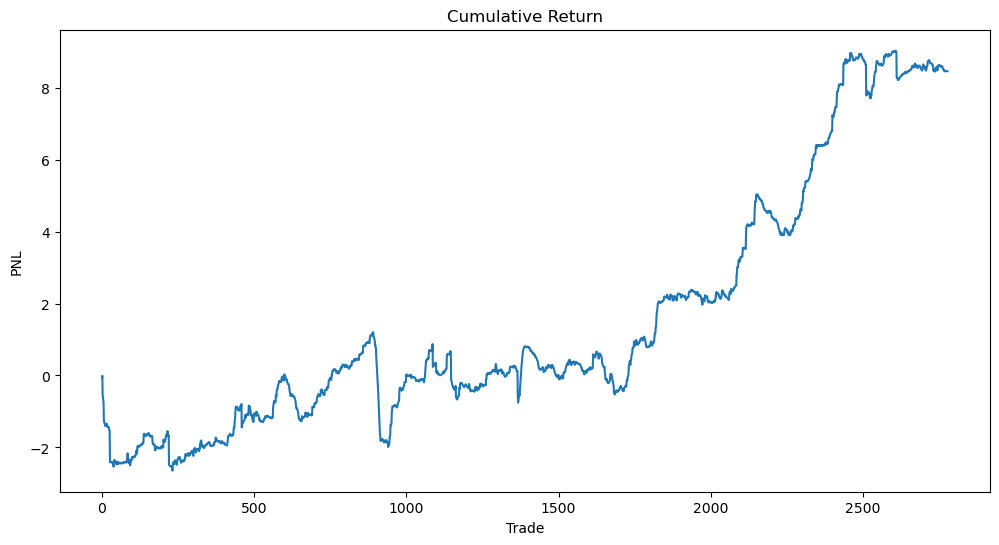

In [45]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
# plot the cumsum PNL
plt.plot(results['Return'].cumsum())
plt.title('Cumulative Return')
plt.xlabel('Trade')
plt.ylabel('PNL')
plt.show()